# Macro-Aware Tactical Asset Allocation Engine

A dynamic, HMM-driven regime-switching portfolio strategy that classifies hidden market states (Bull / Bear / Crisis) from multi-asset returns, VIX, and macroeconomic indicators, then re-optimizes allocations across equities, bonds, and gold under regime-specific risk and turnover constraints. Built as a full walk-forward pipeline — data ingestion → feature engineering → regime detection → convex optimization → backtesting → benchmarking → performance reporting — with explicit safeguards against look-ahead bias and portfolio thrashing.

**Assets:** SPY, QQQ, TLT, IEF, GLD, SHY &nbsp;|&nbsp; **Benchmarks:** 60/40, Equal Weight &nbsp;|&nbsp; **Rebalancing:** Monthly &nbsp;|&nbsp; **Period:** 2010–2026

### 1. Imports
Load the core libraries: `yfinance` for market data, `fredapi` for macroeconomic series, `hmmlearn` for the Hidden Markov regime model, `cvxpy` for convex portfolio optimization, and `sklearn` utilities (`StandardScaler`, `LedoitWolf`) for feature scaling and covariance shrinkage.

In [1]:
# BLOCK 1 : IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from hmmlearn.hmm import GaussianHMM
import cvxpy as cp
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import LedoitWolf
import seaborn as sns
import warnings
from fredapi import Fred
from config import FRED_API_KEY
from dateutil.relativedelta import relativedelta
import os

### 2. Parameters
Central configuration for the entire pipeline: analysis window, asset universe (equities, bonds, gold, cash-equivalent), macro variables, HMM settings (states, covariance type, retraining cadence), walk-forward settings (training window, rebalance frequency), and portfolio constraints (weight bounds, transaction cost, risk-free rate). Keeping these in one place makes the backtest's assumptions explicit and easy to audit.

In [2]:
# BLOCK 2 : PARAMETERS
START_DATE = "2010-01-01"
END_DATE = "2026-01-01"

INITIAL_CAPITAL = 1000000

ASSETS = {
    "SPY": "US Large Cap Equity",
    "QQQ": "US Technology Equity",
    "TLT": "Long-Term Treasury Bonds",
    "IEF": "Intermediate Treasury Bonds",
    "GLD": "Gold ETF",
    "SHY": "Short-Term Treasury / Cash Equivalent"
}

VIX_TICKER = "^VIX"

MACRO_VARIABLES = {
    "CPIAUCSL": "Consumer Price Index",
    "FEDFUNDS": "Federal Funds Rate",
    "DGS10": "10-Year Treasury Yield",
    "DGS2": "2-Year Treasury Yield"
}

DERIVED_FEATURES = [
    "Yield_Spread"      # DGS10 - DGS2
]

N_HIDDEN_STATES = 3
HMM_COVARIANCE_TYPE = "diag"
HMM_MAX_ITER = 500
HMM_RANDOM_STATE = 42

INITIAL_TRAIN_YEARS = 5
RETRAIN_EVERY_MONTHS = 1
REBALANCE_FREQUENCY = "M"

MIN_WEIGHT = 0.00
MAX_WEIGHT = 0.80
TARGET_PORTFOLIO_WEIGHT_SUM = 1.0

TRANSACTION_COST = 0.0005
RISK_FREE_RATE = 0.04

VOLATILITY_WINDOW = 21      # 1 month
RETURN_LOOKBACK = 252       # 1 year
CORRELATION_WINDOW = 63     # 3 months

TRADING_DAYS = 252

FIG_SIZE = (15, 7)
PLOT_STYLE = "ggplot"
SEED = 42

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)
pd.set_option("display.precision", 4)


print("PROJECT PARAMETERS LOADED - ")

print(f"\nAnalysis Period : {START_DATE} → {END_DATE}")
print("\nAsset Universe:")
for ticker, asset in ASSETS.items():
    print(f"  {ticker:<6} : {asset}")
print("\nMarket Volatility Index:")
print(f"  {VIX_TICKER}")
print("\nMacroeconomic Variables:")
for code, name in MACRO_VARIABLES.items():
    print(f"  {code:<10} : {name}")
print("\nDerived Features:")
for feature in DERIVED_FEATURES:
    print(f"  {feature}")

print(f"\nHidden States          : {N_HIDDEN_STATES}")
print(f"Rebalancing Frequency : {REBALANCE_FREQUENCY}")
print(f"Initial Train Window  : {INITIAL_TRAIN_YEARS} Years")
print(f"Maximum Asset Weight  : {MAX_WEIGHT:.0%}")
print(f"Transaction Cost      : {TRANSACTION_COST:.2%}")
print(f"Risk-Free Rate        : {RISK_FREE_RATE:.2%}")

PROJECT PARAMETERS LOADED - 

Analysis Period : 2010-01-01 → 2026-01-01

Asset Universe:
  SPY    : US Large Cap Equity
  QQQ    : US Technology Equity
  TLT    : Long-Term Treasury Bonds
  IEF    : Intermediate Treasury Bonds
  GLD    : Gold ETF
  SHY    : Short-Term Treasury / Cash Equivalent

Market Volatility Index:
  ^VIX

Macroeconomic Variables:
  CPIAUCSL   : Consumer Price Index
  FEDFUNDS   : Federal Funds Rate
  DGS10      : 10-Year Treasury Yield
  DGS2       : 2-Year Treasury Yield

Derived Features:
  Yield_Spread

Hidden States          : 3
Rebalancing Frequency : M
Initial Train Window  : 5 Years
Maximum Asset Weight  : 80%
Transaction Cost      : 0.05%
Risk-Free Rate        : 4.00%


### 3. Initializing
Authenticate with the FRED API and confirm the asset, macro, and volatility tickers that will be pulled in the next step.

In [3]:
# BLOCK 3 : INITIALIZING

fred = Fred(api_key=FRED_API_KEY)
print("FRED API loaded")

print("\nAssets Selected:")
for ticker, description in ASSETS.items():
    print(f"{ticker:<6} : {description}")


print("\nMacroeconomic Variables:")

for code, name in MACRO_VARIABLES.items():
    print(f"{code:<10} : {name}")

print("\nMarket Volatility Index:")
print(VIX_TICKER)

print("\nData sources initialized successfully.")

FRED API loaded

Assets Selected:
SPY    : US Large Cap Equity
QQQ    : US Technology Equity
TLT    : Long-Term Treasury Bonds
IEF    : Intermediate Treasury Bonds
GLD    : Gold ETF
SHY    : Short-Term Treasury / Cash Equivalent

Macroeconomic Variables:
CPIAUCSL   : Consumer Price Index
FEDFUNDS   : Federal Funds Rate
DGS10      : 10-Year Treasury Yield
DGS2       : 2-Year Treasury Yield

Market Volatility Index:
^VIX

Data sources initialized successfully.


### 4. Data Download
Pull daily adjusted close prices for the asset universe and the VIX index from Yahoo Finance over the full analysis period.

In [4]:
# BLOCK 4 : DATA DOWNLOAD

asset_data = yf.download(
    tickers=list(ASSETS.keys()),
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    auto_adjust=True,
    progress=True
)

asset_prices = asset_data["Close"].copy()
print("\n Asset prices downloaded successfully.")

vix_data = yf.download(
    VIX_TICKER,
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    auto_adjust=True,
    progress=True
)

vix = vix_data["Close"].iloc[:, 0]
vix.name = "VIX"

print(" VIX downloaded successfully.")

print("Missing Values\n")
print(asset_prices.isna().sum())
print("\nVIX Missing Values :", vix.isna().sum())

print("Date Range\n")

print("Start :", asset_prices.index.min())
print("End   :", asset_prices.index.max())

market_data = {
    "prices": asset_prices,
    "vix": vix
}

print("\n Market data stored successfully.")

[*********************100%***********************]  6 of 6 completed



 Asset prices downloaded successfully.


[*********************100%***********************]  1 of 1 completed

 VIX downloaded successfully.
Missing Values

Ticker
GLD    0
IEF    0
QQQ    0
SHY    0
SPY    0
TLT    0
dtype: int64

VIX Missing Values : 0
Date Range

Start : 2010-01-04 00:00:00
End   : 2025-12-31 00:00:00

 Market data stored successfully.


### 5. Macroeconomic Data
Download CPI, Fed funds rate, and 2Y/10Y Treasury yields from FRED. These will later be lagged to reflect real-world publication delays before being used as model inputs.

In [5]:
# BLOCK 5 : MACROECONOMIC DATA

macro_data = pd.DataFrame()

for code, description in MACRO_VARIABLES.items():
    series = fred.get_series(
        code,
        observation_start=START_DATE,
        observation_end=END_DATE
    )
    macro_data[code] = series

print("\nAll macroeconomic variables downloaded successfully.")

macro_data.rename(columns={
    "CPIAUCSL": "CPI",
    "FEDFUNDS": "FedFunds",
    "DGS10": "Yield10Y",
    "DGS2": "Yield2Y"
}, inplace=True)

print("\nMissing Values")
display(macro_data.isna().sum())
macro_raw = macro_data.copy()
print("\n Macroeconomic data stored.")


All macroeconomic variables downloaded successfully.

Missing Values


CPI          1
FedFunds     0
Yield10Y    68
Yield2Y     68
dtype: int64


 Macroeconomic data stored.


### 6. Merging and Cleaning
Join asset prices, VIX, and macro series into a single daily-indexed DataFrame. Macro series are forward-filled (since they update less frequently than daily) before dropping any remaining incomplete rows.

In [6]:
# BLOCK 6 : MERGING AND CLEANING

prices = asset_prices.copy()
vix_series = vix.copy()
macro = macro_data.copy()

master_df = prices.join(vix_series, how="outer")
master_df = master_df.join(macro, how="outer")

master_df.sort_index(inplace=True)

macro_columns = [
    "CPI",
    "FedFunds",
    "Yield10Y",
    "Yield2Y"
]

master_df[macro_columns] = (
    master_df[macro_columns]
    .ffill()
)

master_df.dropna(inplace=True)
master_df.index = pd.to_datetime(master_df.index)

print("\nDataset Shape - ")
print(master_df.shape)

print("\nDate Range - ")

print(master_df.index.min())
print(master_df.index.max())

print("\nMissing Values - ")
print(master_df.isna().sum())

print("\nColumns - ")
print(master_df.columns.tolist())

print("\n Master dataset created successfully.")


Dataset Shape - 
(4005, 11)

Date Range - 
2010-02-01 00:00:00
2025-12-31 00:00:00

Missing Values - 
GLD         0
IEF         0
QQQ         0
SHY         0
SPY         0
TLT         0
VIX         0
CPI         0
FedFunds    0
Yield10Y    0
Yield2Y     0
dtype: int64

Columns - 
['GLD', 'IEF', 'QQQ', 'SHY', 'SPY', 'TLT', 'VIX', 'CPI', 'FedFunds', 'Yield10Y', 'Yield2Y']

 Master dataset created successfully.


### 7. Feature Engineering
Construct the feature set used by the HMM: log returns for each asset, VIX changes, the 10Y–2Y yield spread, and rolling SPY volatility. Macro variables are shifted forward (e.g., CPI by ~1 month) to reflect real publication lags, preventing the model from ever seeing macro data before it was actually available — a key safeguard against look-ahead bias.

In [7]:
# BLOCK 7 : FEATURE ENGINEERING
features = master_df.copy()

asset_columns = list(ASSETS.keys())

# Compute log returns for assets
for asset in asset_columns:
    features[f"{asset}_Return"] = np.log(
        features[asset] / features[asset].shift(1)
    )

# VIX change
features["VIX_Change"] = features["VIX"].pct_change()

# Apply lags to macro data to prevent look-ahead bias
features["CPI"] = features["CPI"].shift(22)
features["FedFunds"] = features["FedFunds"].shift(1)
features["Yield10Y"] = features["Yield10Y"].shift(1)
features["Yield2Y"] = features["Yield2Y"].shift(1)

# Compute macroeconomic derived features post-lag
features["Yield_Spread"] = features["Yield10Y"] - features["Yield2Y"]

# Volatility proxy
features["SPY_Volatility"] = (
    features["SPY_Return"]
    .rolling(VOLATILITY_WINDOW)
    .std()
)

features.dropna(inplace=True)

feature_columns = [
    "SPY_Return",
    "TLT_Return",
    "GLD_Return",
    "VIX_Change",
    "Yield_Spread",
    "SPY_Volatility"
]

X = features[feature_columns].copy()

print("\n Feature engineering complete with realistic publication lags.")


 Feature engineering complete with realistic publication lags.


### 8. Walk-Forward Framework
Define the monthly rebalancing schedule and the HMM retraining schedule (every 3 months), and initialize the containers that will store regimes, weights, and turnover. The first rebalance date is set only after an initial 5-year training window has elapsed, ensuring the model never trades before it has sufficient history.

In [8]:
# BLOCK 8 : WALK-FORWARD FRAMEWORK

print("INITIALIZING WALK-FORWARD FRAMEWORK")

rebalance_dates = (
    features
    .resample(REBALANCE_FREQUENCY)
    .last()
    .index
)

# First Rebalance Date

first_rebalance = (
    features.index.min()
    + relativedelta(years=INITIAL_TRAIN_YEARS)
)

rebalance_dates = rebalance_dates[
    rebalance_dates >= first_rebalance
]

print(f"First Rebalance : {rebalance_dates[0].date()}")
print(f"Last Rebalance  : {rebalance_dates[-1].date()}")
print(f"Total Rebalances: {len(rebalance_dates)}")


# HMM Retraining Every 3 months

HMM_RETRAIN_FREQUENCY = 3
retrain_dates = []
last_train = None

for date in rebalance_dates:
    if last_train is None:
        retrain_dates.append(date)
        last_train = date
        continue

    months = (
        (date.year - last_train.year) * 12
        + date.month
        - last_train.month
    )

    if months >= HMM_RETRAIN_FREQUENCY:

        retrain_dates.append(date)
        last_train = date

retrain_dates = pd.DatetimeIndex(retrain_dates)

print(f"\nTotal HMM Retrainings : {len(retrain_dates)}")


predicted_regimes = pd.Series(
    index=rebalance_dates,
    dtype="object"
)

predicted_states = pd.Series(
    index=rebalance_dates,
    dtype="Int64"
)

portfolio_weights = pd.DataFrame(
    index=rebalance_dates,
    columns=ASSETS.keys(),
    dtype=float
)

portfolio_returns = pd.Series(
    index=features.index,
    dtype=float
)

turnover = pd.Series(
    index=rebalance_dates,
    dtype=float
)

transition_matrices = {}

state_statistics = {}

print("\nStorage containers initialized.")

# Summary
print("\nWalk-Forward Configuration - ")

print(f"Training Window        : {INITIAL_TRAIN_YEARS} Years")
print(f"Rebalancing Frequency  : Monthly")
print(f"HMM Retraining         : Every {HMM_RETRAIN_FREQUENCY} Months")
print(f"Hidden States          : {N_HIDDEN_STATES}")

print("\nWalk-forward framework ready.")

INITIALIZING WALK-FORWARD FRAMEWORK
First Rebalance : 2015-03-31
Last Rebalance  : 2025-12-31
Total Rebalances: 130

Total HMM Retrainings : 44

Storage containers initialized.

Walk-Forward Configuration - 
Training Window        : 5 Years
Rebalancing Frequency  : Monthly
HMM Retraining         : Every 3 Months
Hidden States          : 3

Walk-forward framework ready.


### 9. Walk-Forward Regime Classification Engine
Core regime-detection loop. At each rebalance date, the HMM is retrained (every 3 months) using only data available up to that point — an expanding window, never future data. States are dynamically mapped to Bull/Bear/Crisis labels using each state's average VIX and equity return, since raw HMM state indices are arbitrary and unordered across retrainings. A 2-month confirmation rule (hysteresis) is applied before accepting a regime change, reducing whipsaw from single-month noise; Crisis is confirmed after just one month, prioritizing fast reaction to genuine risk-off events. The resulting monthly regime signal is shifted forward by one period before being mapped onto the daily timeline, so a signal computed at month-end T only ever affects allocations from month T+1 onward.

In [9]:
# BLOCK 9: WALK-FORWARD REGIME CLASSIFICATION ENGINE
print("RUNNING WALK-FORWARD REGIME DETECTION")

# Re-initialize specific series tracking parameters
predicted_regimes = pd.Series(index=rebalance_dates, dtype="object")
predicted_states = pd.Series(index=rebalance_dates, dtype="float")
regime_change_flags = pd.Series(index=rebalance_dates, dtype="bool")
transition_matrices = []
last_train_date = None

hmm = None
scaler = None

for rebalance_date in rebalance_dates:
    history = features.loc[:rebalance_date].copy()
    if len(history) < INITIAL_TRAIN_YEARS * TRADING_DAYS:
        continue

    retrain = False

    if last_train_date is None:
        retrain = True
    else:
        months = (
            (rebalance_date.year - last_train_date.year) * 12
            + rebalance_date.month
            - last_train_date.month
        )
        if months >= HMM_RETRAIN_FREQUENCY:
            retrain = True

    # HMM Parameter Estimation & Dynamic Label Alignment

    if retrain:
        train_X = history[feature_columns]
        scaler = StandardScaler()
        train_scaled = scaler.fit_transform(train_X)

        best_hmm = None
        best_score = -np.inf

        for seed_offset in range(5):
            candidate = GaussianHMM(
                n_components=N_HIDDEN_STATES,
                covariance_type=HMM_COVARIANCE_TYPE,
                n_iter=HMM_MAX_ITER,
                random_state=HMM_RANDOM_STATE + seed_offset
            )
            candidate.fit(train_scaled)
            score = candidate.score(train_scaled)

            if score > best_score:
                best_score = score
                best_hmm = candidate

        hmm = best_hmm
        historical_states = hmm.predict(train_scaled)
        history["Hidden_State"] = historical_states

        # Extract regime properties to dynamically build an invariant mapping structure
        stats = history.groupby("Hidden_State").agg({
            "SPY_Return": "mean",
            "TLT_Return": "mean",
            "GLD_Return": "mean",
            "VIX": "mean",
            "SPY_Volatility": "mean"
        })

        # 1. Isolate the absolute highest volatility state as Crisis first
        crisis_state = stats["VIX"].idxmax()

        # 2. Get the remaining two state integers safely
        non_crisis_states = list(set(stats.index) - {crisis_state})

        # 3. Classify remaining states dynamically based on Equity returns
        state_a, state_b = non_crisis_states[0], non_crisis_states[1]
        if stats.loc[state_a, "SPY_Return"] > stats.loc[state_b, "SPY_Return"]:
            bull_state = state_a
            bear_state = state_b
        else:
            bull_state = state_b
            bear_state = state_a

        # 4. Map to stable semantic profiles across the rolling frame
        regime_map = {
            bull_state: "Bull",
            bear_state: "Bear",
            crisis_state: "Crisis"
        }

        last_train_date = rebalance_date

        # Reorder the raw transition matrix from component-index order
        # to fixed semantic order ["Bull", "Bear", "Crisis"] before storing
        label_to_state = {v: k for k, v in regime_map.items()}
        order = [
            label_to_state["Bull"],
            label_to_state["Bear"],
            label_to_state["Crisis"]
        ]
        reordered_transmat = hmm.transmat_[np.ix_(order, order)]
        transition_matrices.append(reordered_transmat)

    # State Attribution for the Rebalance Checkpoint
    current_scaled = scaler.transform(history[feature_columns])
    current_state = hmm.predict(current_scaled)[-1]
    current_regime = regime_map[current_state]

    # Hysteresis: only switch after 2 consecutive confirmations
    if 'last_confirmed_regime' not in dir():
        last_confirmed_regime, pending_regime, pending_count = current_regime, None, 0

    if current_regime == last_confirmed_regime:
        pending_regime, pending_count = None, 0
        is_regime_change = False
    else:
        if current_regime == pending_regime:
            pending_count += 1
        else:
            pending_regime, pending_count = current_regime, 1

        required_confirmations = 1 if current_regime == "Crisis" else 2

        if pending_count >= required_confirmations:
            is_regime_change = True
            last_confirmed_regime = current_regime
            pending_regime, pending_count = None, 0
        else:
            is_regime_change = False        # still pending, not confirmed yet

    predicted_states.loc[rebalance_date] = current_state
    predicted_regimes.loc[rebalance_date] = last_confirmed_regime
    regime_change_flags.loc[rebalance_date] = is_regime_change

print("Completed HMM Loop.")


# TIMELINE ALIGNMENT WITHOUT LOOK-AHEAD BIAS

# A regime signal generated on the last day of Month T dictates allocations for Month T+1.
shifted_regimes = predicted_regimes.shift(1)


features["Regime"] = np.nan

for date, regime in shifted_regimes.dropna().items():
    if date in features.index:
        features.loc[date, "Regime"] = regime


features["Regime"] = features["Regime"].ffill()

print("Shifted regimes mapped to daily timeline without look-ahead bias.")
print("\nRegime Counts Across Rebalance Checkpoints:")
print(predicted_regimes.value_counts())
print("\nFirst Few Realized Regime Shifts:")
print(predicted_regimes.dropna().head())

RUNNING WALK-FORWARD REGIME DETECTION
Completed HMM Loop.
Shifted regimes mapped to daily timeline without look-ahead bias.

Regime Counts Across Rebalance Checkpoints:
Crisis    51
Bull      40
Bear      39
Name: count, dtype: int64

First Few Realized Regime Shifts:
2015-03-31    Bear
2015-04-30    Bear
2015-05-31    Bear
2015-06-30    Bull
2015-07-31    Bull
Freq: ME, dtype: object


### 10. Regime-Aware Optimization with Friction Penalty
For each rebalance date, solve a mean-variance optimization conditioned on the current regime. Expected returns (`mu`) blend a regime-specific EWMA estimate with the long-run average return, shrinking harder in Bear/Crisis to avoid overreacting to noisy short-term signals. The covariance matrix blends a standard Ledoit-Wolf estimate with a downside-only (semivariance) estimate, so the optimizer is penalized more for co-crash risk than for general volatility. Risk aversion (`gamma`), maximum single-asset weight, and the turnover budget all vary by regime — loose in Bull to allow concentration in winners, tight in Bear/Crisis to control risk. An L1 turnover penalty and a hard turnover cap jointly control trading costs and prevent the portfolio from thrashing between corner solutions. A defensive floor forces meaningful allocation to Treasuries/gold during Crisis regimes.

In [10]:
# BLOCK 10 : REGIME-AWARE OPTIMIZATION WITH FRICTION PENALTY
print("REGIME-AWARE PORTFOLIO OPTIMIZATION WITH TURNOVER PENALTY")

# Re-initialize clean storage matching rebalance frequency
portfolio_weights = pd.DataFrame(
    index=rebalance_dates,
    columns=ASSETS.keys(),
    dtype=float
)

n_assets = len(ASSETS)
asset_return_cols = [f"{asset}_Return" for asset in ASSETS.keys()]

# Initialize previous weight array to an Equal-Weight portfolio baseline
prev_w_val = np.ones(n_assets) / n_assets

for rebalance_date in rebalance_dates:
    if pd.isna(predicted_regimes.loc[rebalance_date]):
        continue

    current_regime = predicted_regimes.loc[rebalance_date]

    # Filter historical observations belonging strictly to the current regime up to t-1
    history = features.loc[features.index < rebalance_date]
    history = history[history["Regime"] == current_regime]

    if len(history) < 60:
        # Fallback to current weights if history is insufficient
        portfolio_weights.loc[rebalance_date] = prev_w_val
        continue

    returns_matrix = history[asset_return_cols].tail(120)

    # Compute parameters (Annualized)
    mu_regime = (
        returns_matrix
        .ewm(span=60)
        .mean()
        .iloc[-1]
        .values
    ) * TRADING_DAYS

    # Long-run, all-regime mean as a stable anchor to reduces noise-driven concentration
    mu_long_run = features[asset_return_cols].mean().values * TRADING_DAYS

    if current_regime == "Bull":
        SHRINKAGE = 0.45
    elif current_regime == "Bear":
        SHRINKAGE = 0.60
    else:  # Crisis
        SHRINKAGE = 0.70

    mu = SHRINKAGE * mu_long_run + (1 - SHRINKAGE) * mu_regime
    lw = LedoitWolf()

    Sigma = (
        lw.fit(returns_matrix)
        .covariance_
    ) * TRADING_DAYS

    market_down_mask = returns_matrix.mean(axis=1) < 0
    downside_returns = returns_matrix[market_down_mask]

    if len(downside_returns) >= 20:
        lw_downside = LedoitWolf()
        Sigma_downside = lw_downside.fit(
            downside_returns).covariance_ * TRADING_DAYS
        Sigma = 0.3 * Sigma + 0.7 * Sigma_downside

    # Optimization Setup
    w = cp.Variable(n_assets)

    # 1. Base Utility Formulation
    # Dynamic Risk Aversion based on Market Conditions

    market_vol = history["SPY_Return"].std() * np.sqrt(TRADING_DAYS)

    if current_regime == "Bull":
        gamma = 0.20 if market_vol < 0.18 else 0.60
        utility = (
            mu @ w
            - gamma * cp.quad_form(w, Sigma)
        )

    elif current_regime == "Bear":
        gamma = 2.5 if market_vol < 0.25 else 4.0
        utility = (
            mu @ w
            - gamma * cp.quad_form(w, Sigma)
        )

    else:      # Crisis
        gamma = 7.0
        utility = (
            mu @ w
            - gamma * cp.quad_form(w, Sigma)
        )

    # 2. Friction Regularization (L1 Penalty)
    # Penalize structural shifts based on transaction fee settings
    turnover_friction = TRANSACTION_COST * cp.norm(w - prev_w_val, 1)

    # Complete net objective tracking
    objective = cp.Maximize(utility - turnover_friction)

    # Regime-dependent turnover budget
    is_change = bool(regime_change_flags.loc[rebalance_date]
                     ) if rebalance_date in regime_change_flags.index else True

    if current_regime == "Bull":
        max_turnover = 0.80 if is_change else 0.25
    elif current_regime == "Bear":
        max_turnover = 0.45 if is_change else 0.20
    else:  # Crisis
        max_turnover = 0.65 if is_change else 0.25

    # Long-only allocation bounds
    if current_regime == "Bull":
        regime_max_weight = 0.65
    elif current_regime == "Bear":
        regime_max_weight = 0.45
    else:  # Crisis
        regime_max_weight = 0.35

    constraints = [
        cp.sum(w) == TARGET_PORTFOLIO_WEIGHT_SUM,
        w >= MIN_WEIGHT,
        w <= regime_max_weight,
        cp.norm(w - prev_w_val, 1) <= max_turnover
    ]

    #  Crisis defensive floor
    if current_regime == "Crisis":
        shy_idx = list(ASSETS.keys()).index("SHY")
        ief_idx = list(ASSETS.keys()).index("IEF")
        gld_idx = list(ASSETS.keys()).index("GLD")
        constraints.append(w[shy_idx] + w[ief_idx] + w[gld_idx] >= 0.50)

    problem = cp.Problem(objective, constraints)

    try:
        problem.solve(solver=cp.OSQP, max_iter=10000, verbose=False)

        if w.value is not None:
            cleaned_weights = np.maximum(w.value, 0)
            cleaned_weights = 0.90 * cleaned_weights + 0.10 * prev_w_val
            cleaned_weights /= cleaned_weights.sum()

            portfolio_weights.loc[rebalance_date] = cleaned_weights
            prev_w_val = cleaned_weights.copy()  # Update tracking reference
        else:
            portfolio_weights.loc[rebalance_date] = prev_w_val

    except Exception as e:
        portfolio_weights.loc[rebalance_date] = prev_w_val

print("Regularized Optimization Engine complete.")
display(portfolio_weights.dropna().head())

REGIME-AWARE PORTFOLIO OPTIMIZATION WITH TURNOVER PENALTY
Regularized Optimization Engine complete.


,SPY,QQQ,TLT,IEF,GLD,SHY
2015-03-31,0.1667,0.1667,0.1667,0.1667,0.1667,0.1667
2015-04-30,0.1667,0.1667,0.1667,0.1667,0.1667,0.1667
2015-05-31,0.1667,0.1667,0.1667,0.1667,0.1667,0.1667
2015-06-30,0.1667,0.1667,0.1667,0.1667,0.1667,0.1667
2015-07-31,0.1667,0.1667,0.1667,0.1667,0.1667,0.1667


### 11. Walk-Forward Backtest
Apply the computed weights to realized daily returns. Weights decided at the close of a rebalance date only take effect starting the next trading day (not the same day), avoiding a subtle look-ahead bias where a decision would otherwise "earn" the very return it was computed from. Transaction costs are deducted based on realized turnover at each rebalance, and the resulting daily returns are compounded into an equity curve.

In [11]:
# BLOCK 11 : WALK-FORWARD BACKTEST
print("RUNNING WALK-FORWARD BACKTEST")

# Daily Asset Returns
asset_return_cols = [f"{asset}_Return" for asset in ASSETS.keys()]
daily_returns = features[asset_return_cols].copy()

# Portfolio Value
portfolio_value = pd.Series(index=daily_returns.index, dtype=float)
portfolio_value.iloc[0] = INITIAL_CAPITAL

portfolio_daily_returns = pd.Series(index=daily_returns.index, dtype=float)


# Initial Portfolio
previous_weights = np.zeros(len(ASSETS))

# Walk Forward
for i in range(len(rebalance_dates)):
    rebalance_date = rebalance_dates[i]
    if pd.isna(portfolio_weights.loc[rebalance_date]).any():
        continue

    current_weights = portfolio_weights.loc[rebalance_date].values.astype(
        float)

    current_turnover = np.sum(np.abs(current_weights - previous_weights))
    turnover.loc[rebalance_date] = current_turnover
    transaction_cost = current_turnover * TRANSACTION_COST

    # Holding Period
    if i == len(rebalance_dates) - 1:
        holding_period = daily_returns.loc[
            daily_returns.index >= rebalance_date
        ]

    else:
        next_date = rebalance_dates[i + 1]
        holding_period = daily_returns.loc[
            (daily_returns.index > rebalance_date)
            &
            (daily_returns.index <= next_date)
        ]

    # Daily Portfolio Returns
    returns = holding_period @ current_weights
    # Deduct transaction cost on first day only
    if len(returns) > 0:
        returns.iloc[0] -= transaction_cost

    portfolio_daily_returns.loc[returns.index] = returns
    previous_weights = current_weights.copy()

print("Backtest Complete")


# Portfolio Equity Curve
portfolio_daily_returns = portfolio_daily_returns.fillna(0)

portfolio_value = INITIAL_CAPITAL * (
    1 + portfolio_daily_returns
).cumprod()

print("Final Portfolio Value")
print(portfolio_value.iloc[-1])

display(portfolio_value.tail())

RUNNING WALK-FORWARD BACKTEST
Backtest Complete
Final Portfolio Value
2808379.797353038


2025-12-24    2.8769e+06
2025-12-26    2.8890e+06
2025-12-29    2.8331e+06
2025-12-30    2.8297e+06
2025-12-31    2.8084e+06
dtype: float64

### 12. Static Benchmark Portfolios
Construct two passive baselines — a classic 60/40 (SPY/TLT) and an equal-weight portfolio across all assets — over the exact same date range the dynamic strategy actually trades, ensuring a fair, apples-to-apples comparison rather than giving benchmarks extra compounding time the strategy didn't have.

In [12]:
# BLOCK 12 : STATIC BENCHMARK PORTFOLIOS
print("CREATING BENCHMARK PORTFOLIOS")
# Strategy Start Date - after HMM training period

strategy_start = rebalance_dates[0]

print(f"Benchmark Start Date : {strategy_start.date()}")


# Asset Returns
asset_return_cols = [f"{asset}_Return" for asset in ASSETS.keys()]

benchmark_returns = (
    features.loc[
        features.index >= strategy_start,
        asset_return_cols
    ]
    .copy()
)


# 60 / 40 Benchmark

weights_6040 = pd.Series(
    0.0,
    index=benchmark_returns.columns
)

weights_6040["SPY_Return"] = 0.60
weights_6040["TLT_Return"] = 0.40

benchmark_6040_returns = benchmark_returns @ weights_6040
benchmark_6040_value = (
    INITIAL_CAPITAL
    * (1 + benchmark_6040_returns.fillna(0)).cumprod()
)


# Equal Weight Benchmark
weights_equal = pd.Series(
    1 / len(asset_return_cols),
    index=benchmark_returns.columns
)

benchmark_equal_returns = benchmark_returns @ weights_equal

benchmark_equal_value = (
    INITIAL_CAPITAL
    * (1 + benchmark_equal_returns.fillna(0)).cumprod()
)


# Align Dynamic Strategy

portfolio_daily_returns = (
    portfolio_daily_returns
    .loc[strategy_start:]
    .copy()
)

portfolio_value = (
    portfolio_value
    .loc[strategy_start:]
    .copy()
)

# Ensure Common Timeline

common_index = portfolio_value.index

benchmark_6040_returns = (
    benchmark_6040_returns
    .reindex(common_index)
    .fillna(0)
)

benchmark_equal_returns = (
    benchmark_equal_returns
    .reindex(common_index)
    .fillna(0)
)

benchmark_6040_value = (
    benchmark_6040_value
    .reindex(common_index)
    .ffill()
)

benchmark_equal_value = (
    benchmark_equal_value
    .reindex(common_index)
    .ffill()
)

# Summary

print("\nBenchmarks Created Successfully\n")

print(f"Comparison Start Date          : {strategy_start.date()}")
print(f"Dynamic Strategy Final Value   : ${portfolio_value.iloc[-1]:,.2f}")
print(
    f"60/40 Portfolio Final Value    : ${benchmark_6040_value.iloc[-1]:,.2f}")
print(
    f"Equal Weight Portfolio Value   : ${benchmark_equal_value.iloc[-1]:,.2f}")

print("\nBenchmark Weights\n")

display(
    pd.DataFrame({
        "60/40": weights_6040,
        "Equal Weight": weights_equal
    })
)

CREATING BENCHMARK PORTFOLIOS
Benchmark Start Date : 2015-03-31

Benchmarks Created Successfully

Comparison Start Date          : 2015-03-31
Dynamic Strategy Final Value   : $2,808,379.80
60/40 Portfolio Final Value    : $2,027,869.86
Equal Weight Portfolio Value   : $2,088,170.74

Benchmark Weights



,60/40,Equal Weight
SPY_Return,0.6,0.1667
QQQ_Return,0.0,0.1667
TLT_Return,0.4,0.1667
IEF_Return,0.0,0.1667
GLD_Return,0.0,0.1667
SHY_Return,0.0,0.1667


### 13. Performance Tear Sheet
Compute standard risk-adjusted performance metrics for all three portfolios: CAGR, annualized volatility, Sharpe ratio, Sortino ratio, maximum drawdown, and Calmar ratio (all excess-return metrics correctly net the risk-free rate), plus average turnover for the dynamic strategy.

In [13]:
# BLOCK 13 : PERFORMANCE TEAR SHEET
print("PERFORMANCE ANALYSIS")

# Performance Metric Function


def performance_metrics(returns, portfolio_value):
    returns = returns.dropna()
    cumulative_return = (
        portfolio_value.iloc[-1] / portfolio_value.iloc[0]
    ) - 1

    years = len(returns) / TRADING_DAYS

    cagr = (
        portfolio_value.iloc[-1] / portfolio_value.iloc[0]
    ) ** (1 / years) - 1

    volatility = returns.std() * np.sqrt(TRADING_DAYS)

    sharpe = 0
    if volatility > 0:
        sharpe = (cagr - RISK_FREE_RATE) / volatility

    downside = returns[returns < 0]

    downside_volatility = 0
    if len(downside) > 0:
        downside_volatility = downside.std() * np.sqrt(TRADING_DAYS)

    sortino = 0
    if downside_volatility > 0:
        sortino = (cagr - RISK_FREE_RATE) / downside_volatility

    running_max = portfolio_value.cummax()

    drawdown = (
        portfolio_value - running_max
    ) / running_max

    max_drawdown = drawdown.min()

    calmar = 0
    if max_drawdown != 0:
        calmar = cagr / abs(max_drawdown)

    return {
        "Final Value": portfolio_value.iloc[-1],
        "Cumulative Return": cumulative_return,
        "CAGR": cagr,
        "Annual Volatility": volatility,
        "Sharpe Ratio": sharpe,
        "Sortino Ratio": sortino,
        "Maximum Drawdown": max_drawdown,
        "Calmar Ratio": calmar
    }

# Compute Metrics


dynamic_metrics = performance_metrics(
    portfolio_daily_returns,
    portfolio_value
)

benchmark6040_metrics = performance_metrics(
    benchmark_6040_returns,
    benchmark_6040_value
)

equal_metrics = performance_metrics(
    benchmark_equal_returns,
    benchmark_equal_value
)


# Summary Table

results = pd.DataFrame({
    "Dynamic Strategy": dynamic_metrics,
    "60/40 Portfolio": benchmark6040_metrics,
    "Equal Weight": equal_metrics
})


# Average Turnover
results.loc["Average Turnover"] = pd.Series({
    "Dynamic Strategy": turnover.loc[turnover.index >= strategy_start].mean(),
    "60/40 Portfolio": np.nan,
    "Equal Weight": np.nan
})

formatted = results.copy()

percentage_rows = [
    "Cumulative Return",
    "CAGR",
    "Annual Volatility",
    "Maximum Drawdown",
    "Average Turnover"
]

for row in percentage_rows:
    formatted.loc[row] = results.loc[row].apply(
        lambda x: f"{x*100:.2f}%" if pd.notna(x) else "-"
    )

formatted.loc["Final Value"] = results.loc["Final Value"].apply(
    lambda x: f"${x:,.2f}"
)

ratio_rows = [
    "Sharpe Ratio",
    "Sortino Ratio",
    "Calmar Ratio"
]

for row in ratio_rows:
    formatted.loc[row] = results.loc[row].apply(
        lambda x: f"{x:.3f}" if pd.notna(x) else "-"
    )

print("\nPerformance Summary")
print(
    f"\nEvaluation Period : {strategy_start.date()} → {portfolio_value.index[-1].date()}\n")

display(formatted)

PERFORMANCE ANALYSIS

Performance Summary

Evaluation Period : 2015-03-31 → 2025-12-31



,Dynamic Strategy,60/40 Portfolio,Equal Weight
Final Value,"$2,808,379.80","$2,027,869.86","$2,088,170.74"
Cumulative Return,180.84%,103.68%,109.33%
CAGR,10.09%,6.85%,7.12%
Annual Volatility,13.41%,11.31%,7.94%
Sharpe Ratio,0.454,0.252,0.393
Sortino Ratio,0.553,0.316,0.524
Maximum Drawdown,-31.81%,-28.74%,-22.01%
Calmar Ratio,0.317,0.238,0.324
Average Turnover,22.04%,-,-


### 14. Core Visualizations
Four diagnostic plots: portfolio value comparison, the detected regime timeline, SPY price overlaid with regime labels (visually validating that Crisis periods align with real drawdowns), and the evolving portfolio allocation across assets over time.

GENERATING CORE VISUALIZATIONS


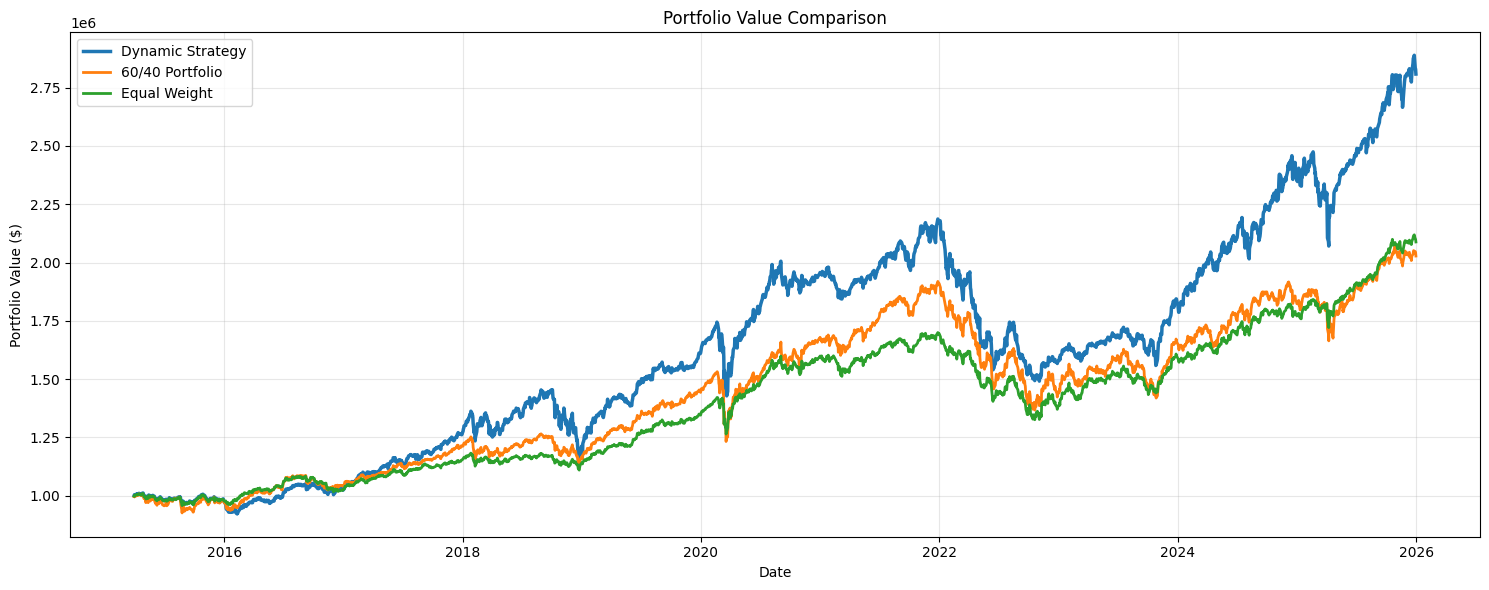

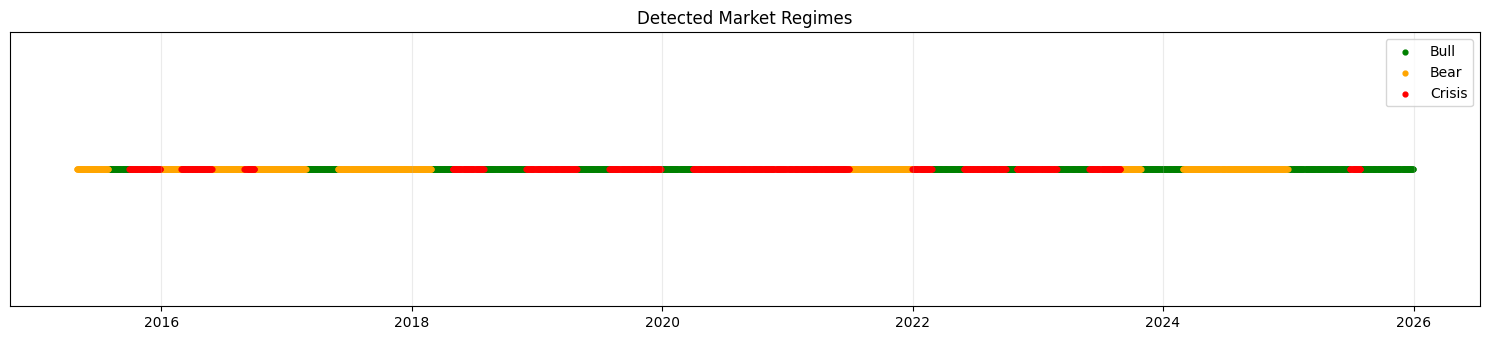

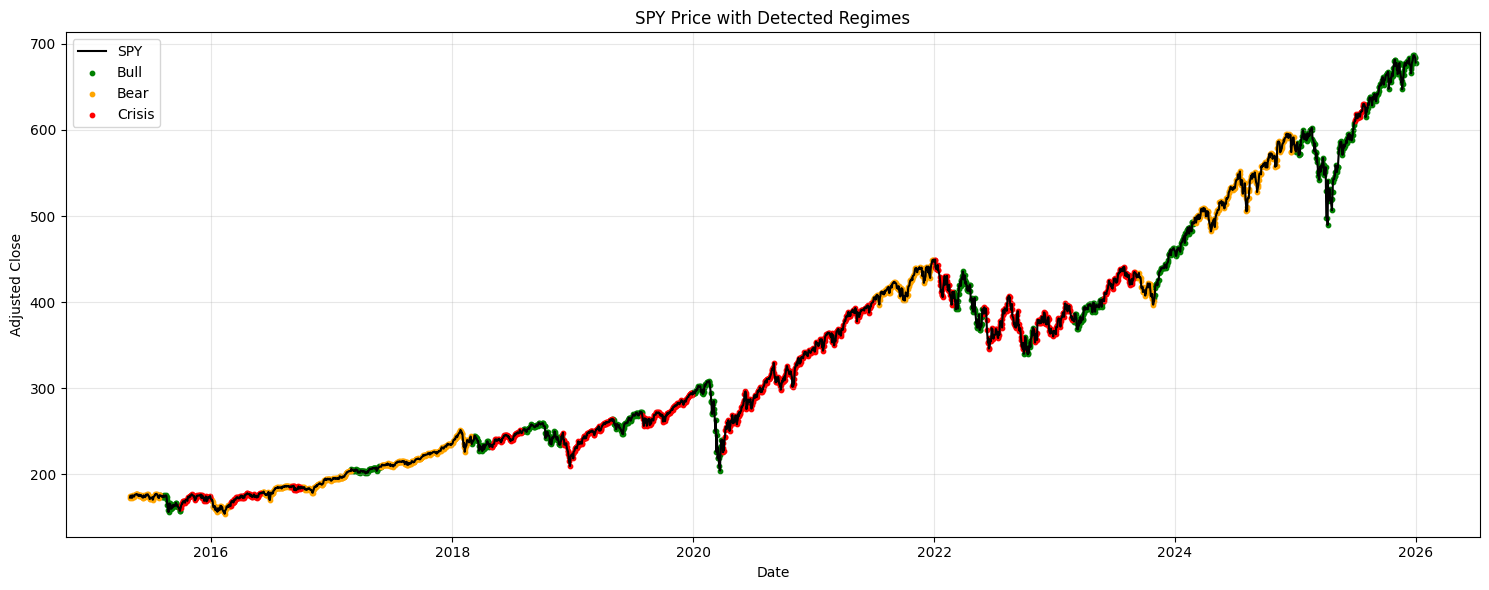

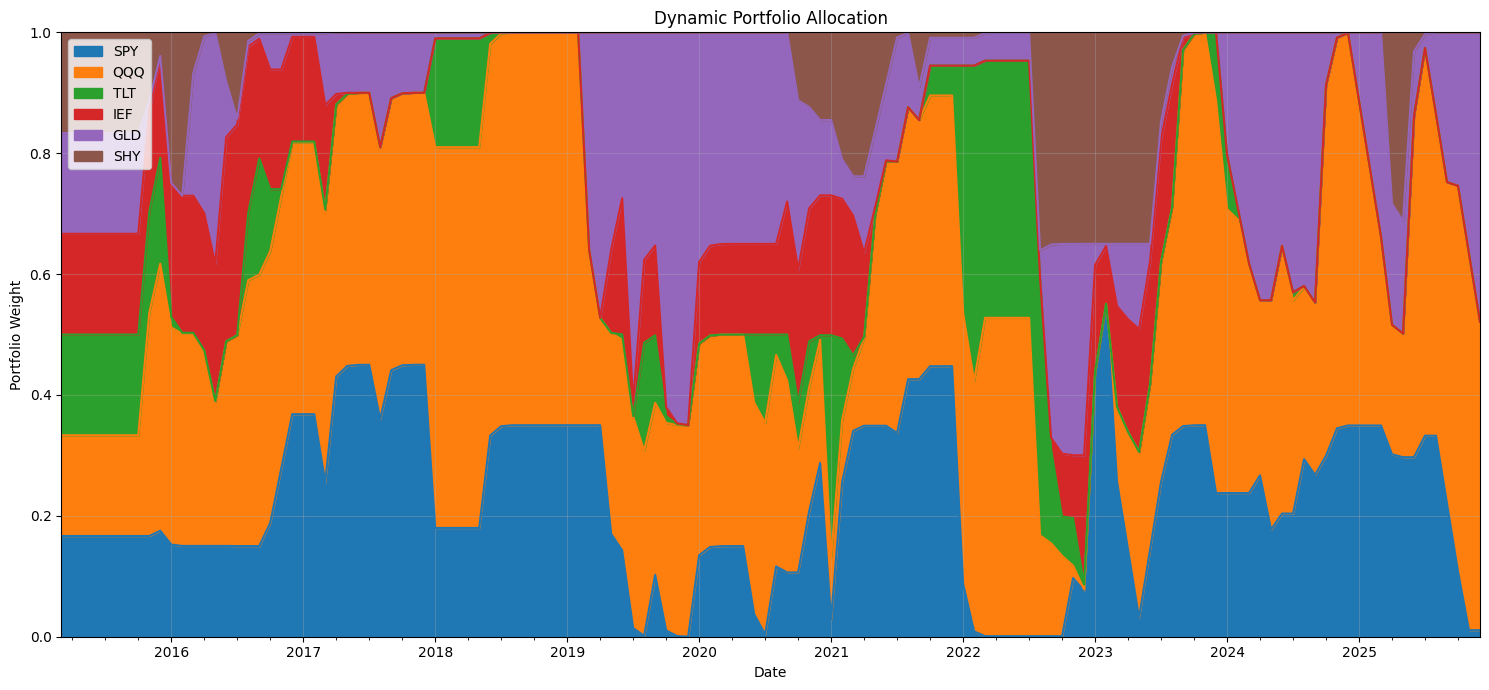

In [14]:
# BLOCK 14 : CORE VISUALIZATIONS
print("GENERATING CORE VISUALIZATIONS")

plot_start = strategy_start

colors = {
    "Bull": "green",
    "Bear": "orange",
    "Crisis": "red"
}

# Plot 1 : Portfolio Value Comparison
plt.figure(figsize=(15, 6))

plt.plot(
    portfolio_value,
    label="Dynamic Strategy",
    linewidth=2.5
)

plt.plot(
    benchmark_6040_value,
    label="60/40 Portfolio",
    linewidth=2
)

plt.plot(
    benchmark_equal_value,
    label="Equal Weight",
    linewidth=2
)

plt.title("Portfolio Value Comparison")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


# Plot 2 : Market Regime Timeline

regime_plot = features.loc[
    features.index >= plot_start
].copy()

plt.figure(figsize=(15, 3.5))

for regime, color in colors.items():

    mask = regime_plot["Regime"] == regime

    plt.scatter(
        regime_plot.index[mask],
        np.ones(mask.sum()),
        color=color,
        s=12,
        label=regime
    )

plt.title("Detected Market Regimes")
plt.yticks([])
plt.grid(alpha=0.25)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc="upper right")

plt.tight_layout()
plt.show()


# Plot 3 : SPY Price with Regimes


spy_plot = pd.DataFrame({
    "SPY": prices["SPY"],
    "Regime": features["Regime"]
})

spy_plot = spy_plot.loc[
    spy_plot.index >= plot_start
].dropna()

plt.figure(figsize=(15, 6))

plt.plot(
    spy_plot.index,
    spy_plot["SPY"],
    color="black",
    linewidth=1.5,
    label="SPY"
)

for regime, color in colors.items():
    mask = spy_plot["Regime"] == regime
    plt.scatter(
        spy_plot.index[mask],
        spy_plot.loc[mask, "SPY"],
        s=10,
        color=color,
        label=regime
    )

plt.title("SPY Price with Detected Regimes")
plt.xlabel("Date")
plt.ylabel("Adjusted Close")
plt.grid(alpha=0.3)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.tight_layout()
plt.show()


# Plot 4 : Portfolio Allocation Through Time

weights_plot = (
    portfolio_weights
    .loc[portfolio_weights.index >= plot_start]
    .copy()
)

weights_plot = weights_plot.clip(lower=0)

weights_plot = weights_plot.div(
    weights_plot.sum(axis=1),
    axis=0
)

plt.figure(figsize=(15, 7))

weights_plot.plot.area(
    ax=plt.gca()
)

plt.title("Dynamic Portfolio Allocation")
plt.xlabel("Date")
plt.ylabel("Portfolio Weight")
plt.ylim(0, 1)

plt.grid(alpha=0.3)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

### 15. Drawdown Comparison
Plot rolling drawdown for all three portfolios on a common axis to directly compare depth and duration of losses, particularly during known stress periods (2018, 2020, 2022).

DRAWDOWN COMPARISON


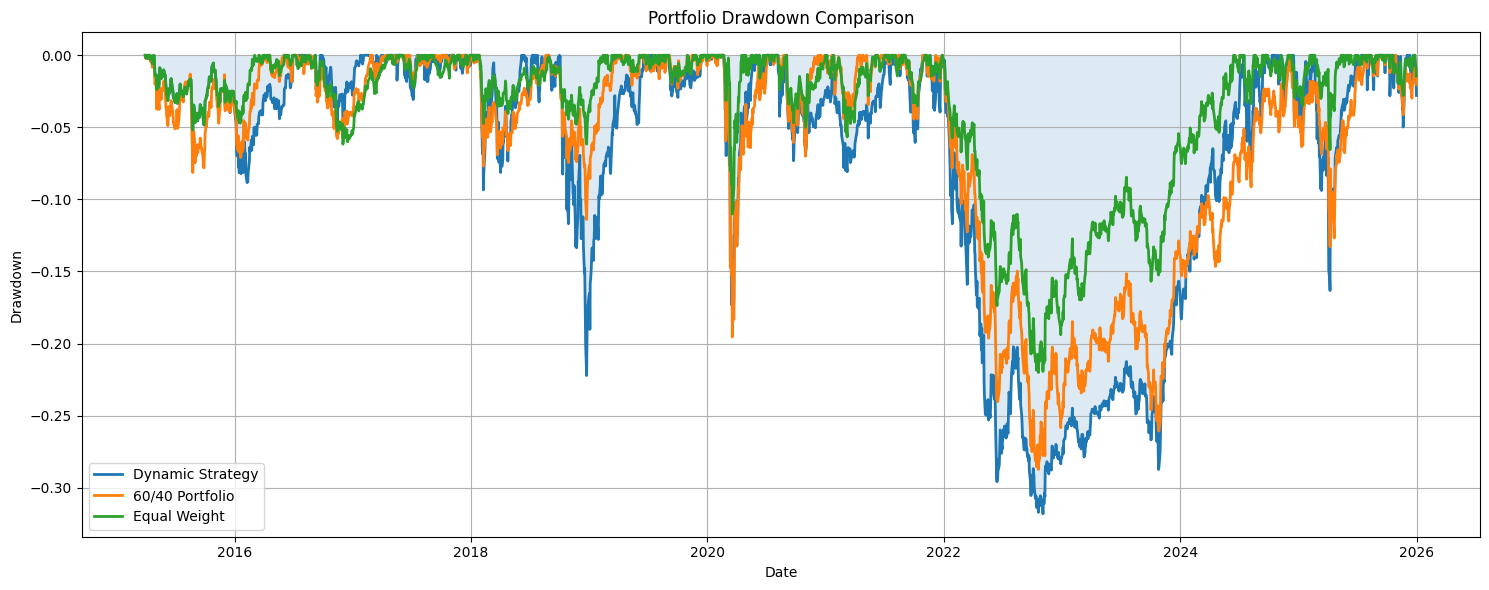

In [15]:
# BLOCK 15 : DRAWDOWN COMPARISON
print("DRAWDOWN COMPARISON")


def compute_drawdown(value_series):
    running_max = value_series.cummax()
    drawdown = (
        value_series - running_max
    ) / running_max
    return drawdown


dynamic_dd = compute_drawdown(portfolio_value)
benchmark6040_dd = compute_drawdown(benchmark_6040_value)
equal_dd = compute_drawdown(benchmark_equal_value)

plt.figure(figsize=(15, 6))

plt.plot(
    dynamic_dd,
    linewidth=2,
    label="Dynamic Strategy"
)

plt.plot(
    benchmark6040_dd,
    linewidth=2,
    label="60/40 Portfolio"
)

plt.plot(
    equal_dd,
    linewidth=2,
    label="Equal Weight"
)

plt.fill_between(
    dynamic_dd.index,
    dynamic_dd,
    0,
    alpha=0.15
)

plt.title("Portfolio Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 16. Rolling 12-Month Sharpe Ratio
Track how risk-adjusted performance evolves through time rather than relying solely on a single full-sample Sharpe figure, revealing whether outperformance is concentrated in specific periods or persistent throughout.

ROLLING 12-MONTH SHARPE RATIO


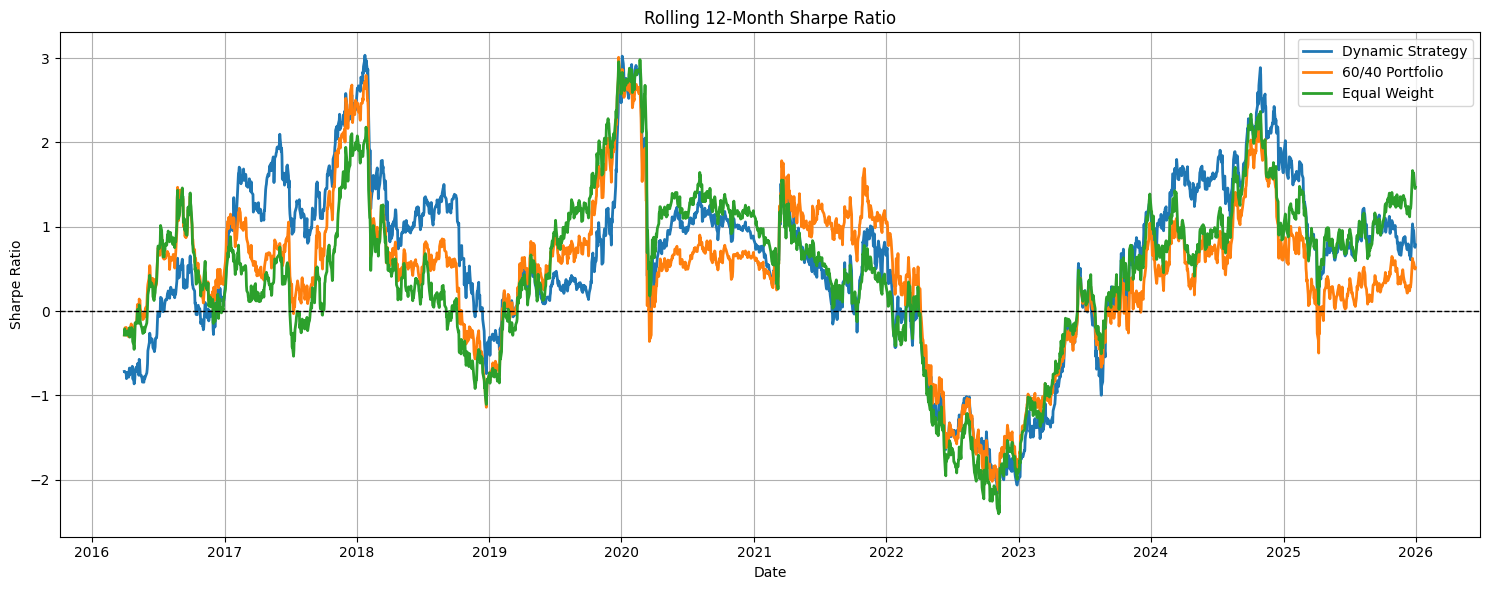

In [16]:
# BLOCK 16 : ROLLING 12-MONTH SHARPE RATIO
print("ROLLING 12-MONTH SHARPE RATIO")

WINDOW = 252   # 12 months


def rolling_sharpe(returns):
    rolling_return = (
        returns
        .rolling(WINDOW)
        .mean()
        * TRADING_DAYS
    )

    rolling_vol = (
        returns
        .rolling(WINDOW)
        .std()
        * np.sqrt(TRADING_DAYS)
    )

    sharpe = (
        rolling_return - RISK_FREE_RATE
    ) / rolling_vol

    return sharpe


dynamic_sharpe = rolling_sharpe(portfolio_daily_returns)

benchmark6040_sharpe = rolling_sharpe(
    benchmark_6040_returns
)

equal_sharpe = rolling_sharpe(
    benchmark_equal_returns
)

plt.figure(figsize=(15, 6))
plt.plot(
    dynamic_sharpe,
    linewidth=2,
    label="Dynamic Strategy"
)

plt.plot(
    benchmark6040_sharpe,
    linewidth=2,
    label="60/40 Portfolio"
)

plt.plot(
    equal_sharpe,
    linewidth=2,
    label="Equal Weight"
)

plt.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title("Rolling 12-Month Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 17. Rolling 12-Month Annualized Volatility
Visualize how each portfolio's realized risk level shifts over time, checking whether the dynamic strategy's regime-switching actually reduces risk during turbulent periods as intended.

ROLLING 12-MONTH ANNUALIZED VOLATILITY


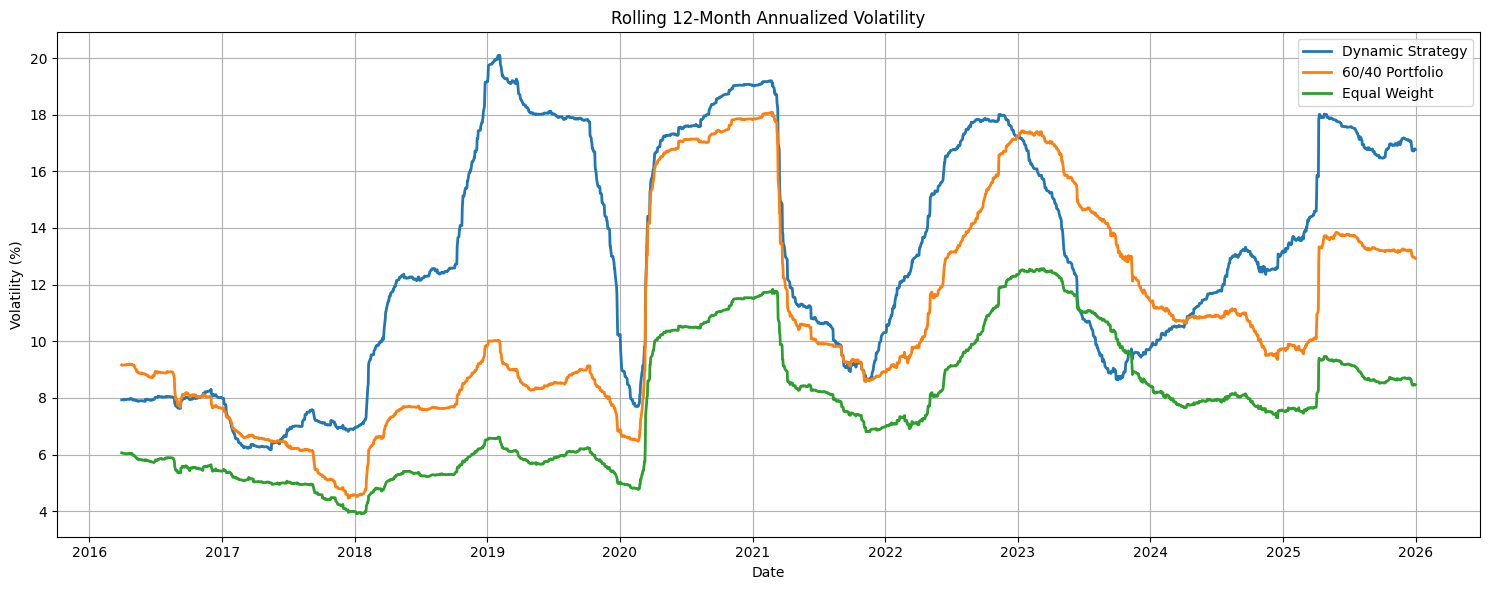

In [17]:
# BLOCK 17 : ROLLING 12-MONTH ANNUALIZED VOLATILITY
print("ROLLING 12-MONTH ANNUALIZED VOLATILITY")

WINDOW = 252


def rolling_volatility(returns):
    return (
        returns
        .rolling(WINDOW)
        .std()
        * np.sqrt(TRADING_DAYS)
        * 100
    )


rolling_vol_dynamic = rolling_volatility(
    portfolio_daily_returns
)

rolling_vol_6040 = rolling_volatility(
    benchmark_6040_returns
)

rolling_vol_equal = rolling_volatility(
    benchmark_equal_returns)


plt.figure(figsize=(15, 6))
plt.plot(
    rolling_vol_dynamic,
    linewidth=2,
    label="Dynamic Strategy"
)

plt.plot(
    rolling_vol_6040,
    linewidth=2,
    label="60/40 Portfolio"
)

plt.plot(
    rolling_vol_equal,
    linewidth=2,
    label="Equal Weight"
)

plt.title("Rolling 12-Month Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 18. Monthly Returns Heatmaps
Calendar heatmaps of monthly returns for the dynamic strategy, the 60/40 benchmark, and the equal-weight benchmark, making it easy to spot which specific months/years drove performance differences.

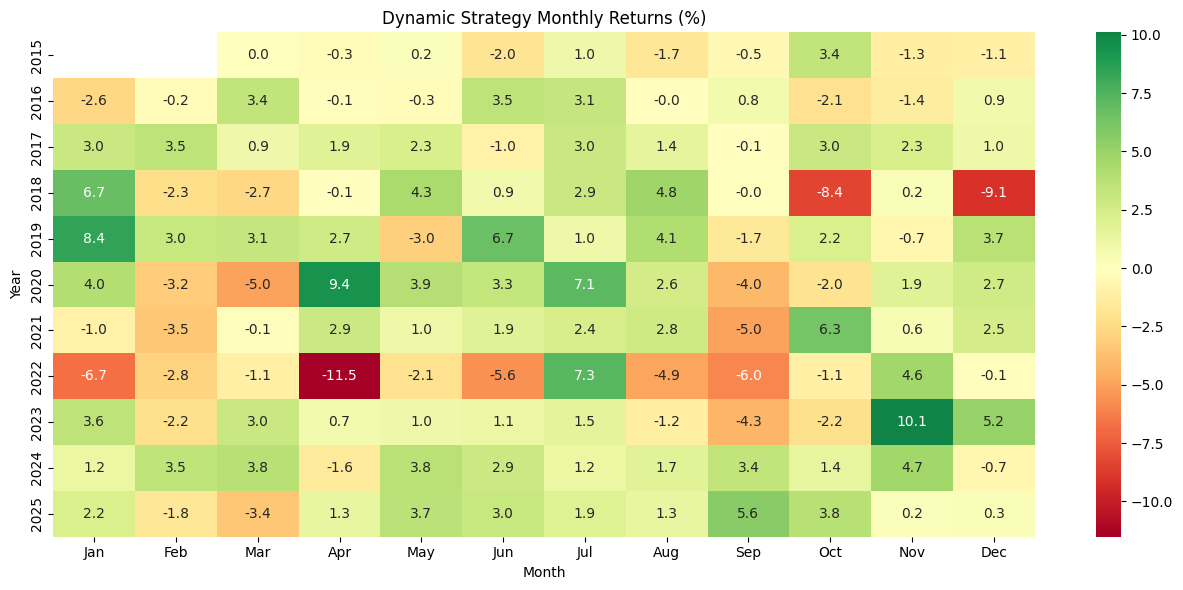

In [18]:
# BLOCK 18A : MONTHLY RETURNS HEATMAP (DYNAMIC STRATEGY)
dynamic_monthly = (
    portfolio_daily_returns
    .loc[strategy_start:]
    .resample("M")
    .apply(lambda x: (1 + x).prod() - 1)
)

heatmap = pd.DataFrame({
    "Return": dynamic_monthly
})

heatmap["Year"] = heatmap.index.year
heatmap["Month"] = heatmap.index.strftime("%b")

heatmap = heatmap.pivot(
    index="Year",
    columns="Month",
    values="Return"
)

month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

heatmap = heatmap.reindex(columns=month_order)

plt.figure(figsize=(13, 6))

sns.heatmap(
    heatmap*100,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    center=0
)

plt.title("Dynamic Strategy Monthly Returns (%)")

plt.tight_layout()
plt.show()

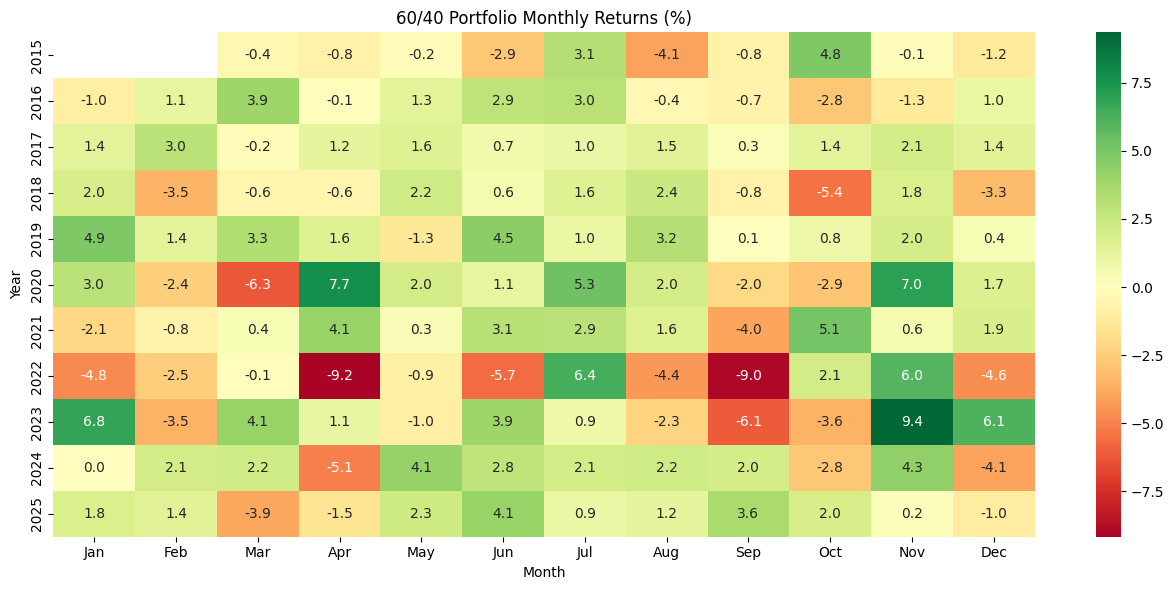

In [19]:
# BLOCK 18B : MONTHLY RETURNS HEATMAP (60/40)

benchmark_monthly = (
    benchmark_6040_returns
    .loc[strategy_start:]
    .resample("M")
    .apply(lambda x: (1 + x).prod() - 1)
)

heatmap = pd.DataFrame({
    "Return": benchmark_monthly
})

heatmap["Year"] = heatmap.index.year
heatmap["Month"] = heatmap.index.strftime("%b")

heatmap = heatmap.pivot(
    index="Year",
    columns="Month",
    values="Return"
)

heatmap = heatmap.reindex(columns=month_order)

plt.figure(figsize=(13, 6))

sns.heatmap(
    heatmap*100,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    center=0
)

plt.title("60/40 Portfolio Monthly Returns (%)")

plt.tight_layout()
plt.show()

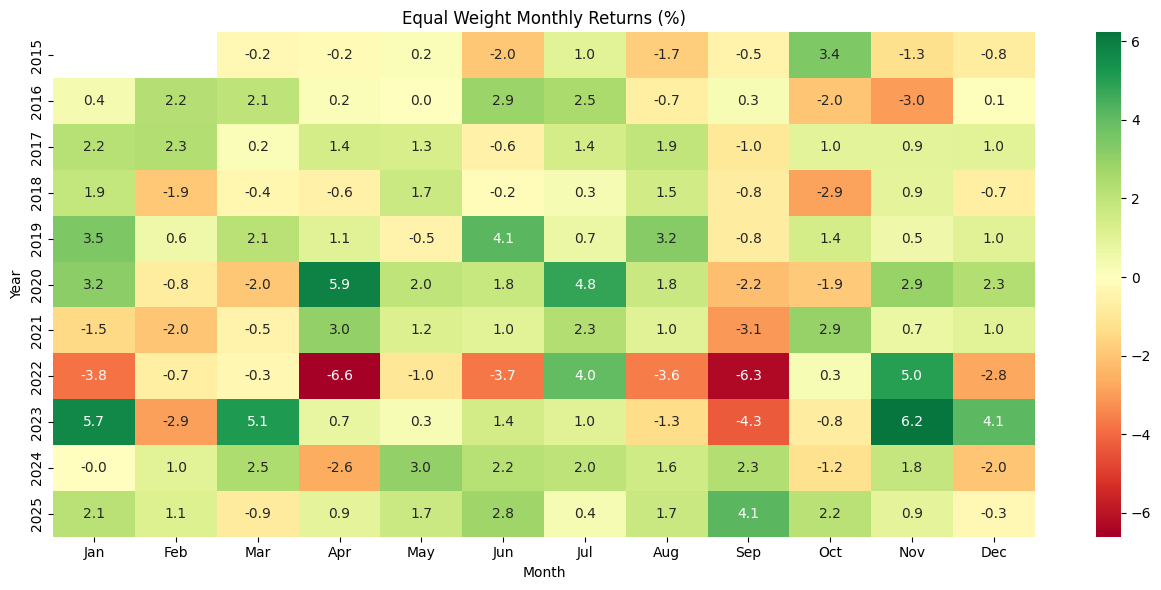

In [20]:
# BLOCK 18C : MONTHLY RETURNS HEATMAP (EQUAL WEIGHT)

equal_monthly = (
    benchmark_equal_returns
    .loc[strategy_start:]
    .resample("M")
    .apply(lambda x: (1 + x).prod() - 1)
)

heatmap = pd.DataFrame({
    "Return": equal_monthly
})

heatmap["Year"] = heatmap.index.year
heatmap["Month"] = heatmap.index.strftime("%b")

heatmap = heatmap.pivot(
    index="Year",
    columns="Month",
    values="Return"
)

heatmap = heatmap.reindex(columns=month_order)

plt.figure(figsize=(13, 6))

sns.heatmap(
    heatmap*100,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    center=0
)

plt.title("Equal Weight Monthly Returns (%)")

plt.tight_layout()
plt.show()

### 19. Export Results & Project Summary
Persist all key outputs (weights, regimes, equity curves, returns, transition matrix, drawdowns, rolling metrics, figures) to disk as CSVs/PNGs for reproducibility, and print a final summary of the pipeline configuration and results.

In [21]:
# BLOCK 19 : EXPORT RESULTS & PROJECT SUMMARY
print("EXPORTING RESULTS")

# Create Results Folder
RESULTS_DIR = "results"


# Evaluation-period series (strategy start onwards)
dynamic_returns = portfolio_daily_returns.loc[strategy_start:].copy()
dynamic_value = portfolio_value.loc[strategy_start:].copy()

benchmark6040_returns = benchmark_6040_returns.loc[strategy_start:].copy()
benchmark6040_value = benchmark_6040_value.loc[strategy_start:].copy()

equal_returns = benchmark_equal_returns.loc[strategy_start:].copy()
equal_value = benchmark_equal_value.loc[strategy_start:].copy()

os.makedirs(RESULTS_DIR, exist_ok=True)


# Save Portfolio Weights
portfolio_weights.to_csv(
    os.path.join(RESULTS_DIR, "portfolio_weights.csv")
)

# Save Predicted Regimes
predicted_regimes.to_csv(
    os.path.join(RESULTS_DIR, "predicted_regimes.csv"),
    header=["Regime"]
)


# Save Portfolio Values
portfolio_value.to_csv(
    os.path.join(RESULTS_DIR, "dynamic_portfolio_value.csv"),
    header=["Portfolio Value"]
)

benchmark_6040_value.to_csv(
    os.path.join(RESULTS_DIR, "benchmark_6040_value.csv"),
    header=["Portfolio Value"]
)

benchmark_equal_value.to_csv(
    os.path.join(RESULTS_DIR, "benchmark_equal_value.csv"),
    header=["Portfolio Value"]
)


# Save Daily Returns
portfolio_daily_returns.to_csv(
    os.path.join(RESULTS_DIR, "dynamic_daily_returns.csv"),
    header=["Return"]
)

benchmark_6040_returns.to_csv(
    os.path.join(RESULTS_DIR, "benchmark_6040_returns.csv"),
    header=["Return"]
)

benchmark_equal_returns.to_csv(
    os.path.join(RESULTS_DIR, "benchmark_equal_returns.csv"),
    header=["Return"]
)


# Save Performance Summary
formatted.to_csv(
    os.path.join(RESULTS_DIR, "performance_summary.csv")
)


# Save Turnover
turnover.to_csv(
    os.path.join(RESULTS_DIR, "turnover.csv"),
    header=["Turnover"]
)


# Save Latest Transition Matrix
if len(transition_matrices) > 0:

    transition_df = pd.DataFrame(
        transition_matrices[-1],
        index=["Bull", "Bear", "Crisis"],
        columns=["Bull", "Bear", "Crisis"]
    )

    transition_df.to_csv(
        os.path.join(
            RESULTS_DIR,
            "transition_matrix.csv"
        )
    )

    print("\nLatest Transition Matrix\n")
    display(transition_df.style.format("{:.4f}"))

# Save Latest Portfolio Weights

latest_weights = portfolio_weights.dropna().iloc[-1]

latest_weights.to_csv(
    os.path.join(
        RESULTS_DIR,
        "latest_portfolio_weights.csv"
    ),
    header=["Weight"]
)


# Save Regime Timeline
features[["Regime"]].to_csv(
    os.path.join(
        RESULTS_DIR,
        "regime_timeline.csv"
    )
)

# Save Annual Returns

annual_returns = pd.DataFrame({
    "Dynamic":
        dynamic_returns.resample("Y").apply(
            lambda x: (1 + x).prod() - 1
        ),
    "60_40":
        benchmark6040_returns.resample("Y").apply(
            lambda x: (1 + x).prod() - 1
        ),
    "EqualWeight":
        equal_returns.resample("Y").apply(
            lambda x: (1 + x).prod() - 1
        )
})

annual_returns.index = annual_returns.index.year

annual_returns.to_csv(
    os.path.join(
        RESULTS_DIR,
        "annual_returns.csv"
    )
)

# Save Monthly Returns

monthly_returns = pd.DataFrame({
    "Dynamic":
        dynamic_returns.resample("M").apply(
            lambda x: (1 + x).prod() - 1
        ),
    "60_40":
        benchmark6040_returns.resample("M").apply(
            lambda x: (1 + x).prod() - 1
        ),
    "EqualWeight":
        equal_returns.resample("M").apply(
            lambda x: (1 + x).prod() - 1
        )
})

monthly_returns.to_csv(
    os.path.join(
        RESULTS_DIR,
        "monthly_returns.csv"
    )
)

# Save Rolling Metrics
rolling_metrics = pd.DataFrame({
    "Dynamic Sharpe": dynamic_sharpe,
    "60/40 Sharpe": benchmark6040_sharpe,
    "Equal Sharpe": equal_sharpe,
    "Dynamic Volatility": rolling_vol_dynamic,
    "60/40 Volatility": rolling_vol_6040,
    "Equal Volatility": rolling_vol_equal
})

rolling_metrics.to_csv(
    os.path.join(
        RESULTS_DIR,
        "rolling_metrics.csv"
    )
)

# Save Drawdowns
drawdowns = pd.DataFrame({
    "Dynamic":
        portfolio_value / portfolio_value.cummax() - 1,
    "60_40":
        benchmark_6040_value /
        benchmark_6040_value.cummax() - 1,
    "EqualWeight":
        benchmark_equal_value /
        benchmark_equal_value.cummax() - 1
})

drawdowns.to_csv(
    os.path.join(
        RESULTS_DIR,
        "drawdowns.csv"
    )
)

# Save Current Figures
for i in plt.get_fignums():

    fig = plt.figure(i)

    fig.savefig(
        os.path.join(
            RESULTS_DIR,
            f"Figure_{i}.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )
# Project Summary

print("\nPROJECT SUMMARY - ")


print(f"Analysis Period           : {START_DATE} to {END_DATE}")
print(f"Strategy Start            : {strategy_start.date()}")
print(f"Assets                    : {', '.join(ASSETS.keys())}")
print(f"Hidden States             : {N_HIDDEN_STATES}")
print(f"Rebalancing               : Monthly")
print(f"Training Window           : {INITIAL_TRAIN_YEARS} Years")
print(f"HMM Retraining            : Every {HMM_RETRAIN_FREQUENCY} Months")
print(f"Maximum Asset Weight      : {MAX_WEIGHT:.0%}")
print(f"Transaction Cost          : {TRANSACTION_COST:.2%}")

print("\nFeatures Used:")

for feature in feature_columns:
    print(f"   • {feature}")

print("\nFinal Performance")

display(formatted)

print("\nLatest Portfolio Allocation")

display(
    latest_weights.to_frame("Weight").style.format("{:.4f}")
)

print("\nResults saved to:")
print(f"   {RESULTS_DIR}/")

print("\nExported Files")
print("-"*40)

files = [
    "portfolio_weights.csv",
    "predicted_regimes.csv",
    "dynamic_portfolio_value.csv",
    "benchmark_6040_value.csv",
    "benchmark_equal_value.csv",
    "dynamic_daily_returns.csv",
    "benchmark_6040_returns.csv",
    "benchmark_equal_returns.csv",
    "performance_summary.csv",
    "transition_matrix.csv",
    "latest_portfolio_weights.csv",
    "regime_timeline.csv",
    "annual_returns.csv",
    "monthly_returns.csv",
    "rolling_metrics.csv",
    "drawdowns.csv",
    "Figure_*.png"
]

for file in files:
    print(f" {file}")

print("\nPipeline Completed")

steps = [
    "Data Collection",
    "Macroeconomic Data Integration",
    "Feature Engineering",
    "Walk-Forward Validation",
    "Hidden Markov Model Regime Detection",
    "Regime-Aware Portfolio Optimization",
    "Transaction Cost Modelling",
    "Portfolio Backtesting",
    "Benchmark Comparison",
    "Performance Analytics",
    "Advanced Visualizations",
    "Results Export"
]

for step in steps:
    print(f" {step}")

print("\nPROJECT COMPLETED SUCCESSFULLY")

EXPORTING RESULTS

Latest Transition Matrix



,Bull,Bear,Crisis
Bull,0.9756,0.0000,0.0244
Bear,0.0000,0.9873,0.0127
Crisis,0.0610,0.0304,0.9087



PROJECT SUMMARY - 
Analysis Period           : 2010-01-01 to 2026-01-01
Strategy Start            : 2015-03-31
Assets                    : SPY, QQQ, TLT, IEF, GLD, SHY
Hidden States             : 3
Rebalancing               : Monthly
Training Window           : 5 Years
HMM Retraining            : Every 3 Months
Maximum Asset Weight      : 80%
Transaction Cost          : 0.05%

Features Used:
   • SPY_Return
   • TLT_Return
   • GLD_Return
   • VIX_Change
   • Yield_Spread
   • SPY_Volatility

Final Performance


,Dynamic Strategy,60/40 Portfolio,Equal Weight
Final Value,"$2,808,379.80","$2,027,869.86","$2,088,170.74"
Cumulative Return,180.84%,103.68%,109.33%
CAGR,10.09%,6.85%,7.12%
Annual Volatility,13.41%,11.31%,7.94%
Sharpe Ratio,0.454,0.252,0.393
Sortino Ratio,0.553,0.316,0.524
Maximum Drawdown,-31.81%,-28.74%,-22.01%
Calmar Ratio,0.317,0.238,0.324
Average Turnover,22.04%,-,-



Latest Portfolio Allocation


,Weight
SPY,0.0108
QQQ,0.5103
TLT,0.0000
IEF,0.0000
GLD,0.4789
SHY,0.0000



Results saved to:
   results/

Exported Files
----------------------------------------
 portfolio_weights.csv
 predicted_regimes.csv
 dynamic_portfolio_value.csv
 benchmark_6040_value.csv
 benchmark_equal_value.csv
 dynamic_daily_returns.csv
 benchmark_6040_returns.csv
 benchmark_equal_returns.csv
 performance_summary.csv
 transition_matrix.csv
 latest_portfolio_weights.csv
 regime_timeline.csv
 annual_returns.csv
 monthly_returns.csv
 rolling_metrics.csv
 drawdowns.csv
 Figure_*.png

Pipeline Completed
 Data Collection
 Macroeconomic Data Integration
 Feature Engineering
 Walk-Forward Validation
 Hidden Markov Model Regime Detection
 Regime-Aware Portfolio Optimization
 Transaction Cost Modelling
 Portfolio Backtesting
 Benchmark Comparison
 Performance Analytics
 Advanced Visualizations
 Results Export

PROJECT COMPLETED SUCCESSFULLY
